# K-Means Clustering for Stock Market Data

## Objective

The objective of this project is to apply K-Means clustering to historical stock market data and group stocks based on their price and trading characteristics.

The project includes data preprocessing, feature engineering, feature scaling, determining the optimal number of clusters using the Elbow Method, applying K-Means clustering, visualizing the clusters, and interpreting the resulting stock groups.

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings("ignore")

In [28]:
# Load the stock prices dataset
df = pd.read_csv("2) Stock Prices Data Set.csv")

# Display the first five rows
df.head()

,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391


In [29]:
# Check the number of rows and columns
print("Dataset Shape:", df.shape)

# Check column names and data types
print("\nDataset Information:")
df.info()

Dataset Shape: (497472, 7)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 497472 entries, 0 to 497471
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   symbol  497472 non-null  object 
 1   date    497472 non-null  object 
 2   open    497461 non-null  float64
 3   high    497464 non-null  float64
 4   low     497464 non-null  float64
 5   close   497472 non-null  float64
 6   volume  497472 non-null  int64  
dtypes: float64(4), int64(1), object(2)
memory usage: 26.6+ MB


In [30]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())

# Check for duplicate rows
print("\nNumber of Duplicate Rows:", df.duplicated().sum())

Missing Values:
symbol     0
date       0
open      11
high       8
low        8
close      0
volume     0
dtype: int64

Number of Duplicate Rows: 0


In [31]:
# Number of unique stocks
print("Number of Unique Stocks:", df["symbol"].nunique())

# Convert date column to datetime
df["date"] = pd.to_datetime(df["date"])

# Display the date range
print("Date Range:", df["date"].min(), "to", df["date"].max())

Number of Unique Stocks: 505
Date Range: 2014-01-02 00:00:00 to 2017-12-29 00:00:00


## Dataset Overview

The dataset contains historical stock market information, including stock symbols, dates, opening prices, highest prices, lowest prices, closing prices, and trading volume.

The initial inspection examines the dataset structure, data types, missing values, duplicate records, number of unique stocks, and the available time period.

## Data Cleaning

Before applying K-Means clustering, the dataset is cleaned by handling missing values and preparing the numerical features required for clustering.

In [32]:
# Check missing values in numerical columns
df[["open", "high", "low", "close", "volume"]].isnull().sum()

open      11
high       8
low        8
close      0
volume     0
dtype: int64

In [33]:
# Fill missing numerical values with their median
numeric_columns = ["open", "high", "low", "close", "volume"]

for column in numeric_columns:
    df[column] = df[column].fillna(df[column].median())

# Verify missing values have been handled
print("Missing values after cleaning:")
print(df[numeric_columns].isnull().sum())

Missing values after cleaning:
open      0
high      0
low       0
close     0
volume    0
dtype: int64


## Feature Engineering

To make the clustering meaningful, the daily stock records are aggregated at the stock level. Features are created to represent average price, trading activity, daily price movement, and volatility.

In [34]:
# Create daily price-based features
df["daily_return"] = (df["close"] - df["open"]) / df["open"]
df["daily_range"] = (df["high"] - df["low"]) / df["open"]

# Aggregate historical data for each stock
stock_features = df.groupby("symbol").agg(
    avg_open=("open", "mean"),
    avg_high=("high", "mean"),
    avg_low=("low", "mean"),
    avg_close=("close", "mean"),
    avg_volume=("volume", "mean"),
    avg_daily_return=("daily_return", "mean"),
    return_volatility=("daily_return", "std"),
    avg_daily_range=("daily_range", "mean")
).reset_index()

# Display the first few rows
stock_features.head()

,symbol,avg_open,avg_high,avg_low,avg_close,avg_volume,avg_daily_return,return_volatility,avg_daily_range
0,A,49.085571,49.485352,48.680860,49.097726,2.191932e+06,0.000396,0.011541,0.016803
1,AAL,42.420103,43.037743,41.799285,42.424900,9.751521e+06,0.000448,0.019364,0.029700
2,AAP,143.205079,144.716834,141.663015,143.187120,1.137307e+06,-0.000077,0.014471,0.021751
3,AAPL,116.811396,117.747015,115.856082,116.839892,4.516957e+07,0.000340,0.011529,0.016491
4,ABBV,63.296754,63.960244,62.651796,63.338302,8.408836e+06,0.000712,0.014620,0.021021


In [35]:
# Check the shape of the engineered dataset
print("Stock-level dataset shape:", stock_features.shape)

# Check for missing values
print("\nMissing values:")
print(stock_features.isnull().sum())

# Display summary statistics
stock_features.describe()

Stock-level dataset shape: (505, 9)

Missing values:
symbol               0
avg_open             0
avg_high             0
avg_low              0
avg_close            0
avg_volume           0
avg_daily_return     0
return_volatility    0
avg_daily_range      0
dtype: int64


,avg_open,avg_high,avg_low,avg_close,avg_volume,avg_daily_return,return_volatility,avg_daily_range
count,505.000000,505.000000,505.000000,505.000000,5.050000e+02,505.000000,505.000000,505.000000
mean,85.807686,86.583222,85.011513,85.823274,4.242756e+06,0.000301,0.013311,0.019237
std,96.961435,97.802346,96.064504,96.962993,6.679430e+06,0.000599,0.010255,0.005411
min,5.911949,6.033305,5.785591,5.908605,1.719199e+05,-0.006416,0.007059,0.010959
25%,43.840030,44.231428,43.466800,43.850695,1.331588e+06,0.000121,0.010228,0.015670
50%,66.510118,67.026813,65.995759,66.545318,2.282951e+06,0.000329,0.011847,0.017981
75%,98.786877,99.562231,98.035614,98.817110,4.304877e+06,0.000543,0.014513,0.021661
max,1390.184151,1402.185641,1377.425447,1390.272642,8.936290e+07,0.006973,0.224508,0.051978


### Observation

The daily stock records have been aggregated to create one row for each stock. The engineered features capture price levels, trading volume, daily price movement, and volatility, providing meaningful numerical variables for clustering.

## Feature Selection and Scaling

Only numerical features that describe stock price behavior, trading activity, and volatility are selected for clustering. The stock symbol is excluded because it is an identifier rather than a numerical feature.

Since the selected features have different scales, standardization is applied before K-Means clustering.

In [36]:
# Select numerical features for clustering
features = [
    "avg_open",
    "avg_high",
    "avg_low",
    "avg_close",
    "avg_volume",
    "avg_daily_return",
    "return_volatility",
    "avg_daily_range"
]

X = stock_features[features]

# Display the selected features
X.head()

,avg_open,avg_high,avg_low,avg_close,avg_volume,avg_daily_return,return_volatility,avg_daily_range
0,49.085571,49.485352,48.680860,49.097726,2.191932e+06,0.000396,0.011541,0.016803
1,42.420103,43.037743,41.799285,42.424900,9.751521e+06,0.000448,0.019364,0.029700
2,143.205079,144.716834,141.663015,143.187120,1.137307e+06,-0.000077,0.014471,0.021751
3,116.811396,117.747015,115.856082,116.839892,4.516957e+07,0.000340,0.011529,0.016491
4,63.296754,63.960244,62.651796,63.338302,8.408836e+06,0.000712,0.014620,0.021021


In [37]:
# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert the scaled data back to a DataFrame
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

# Display the scaled features
X_scaled_df.head()

,avg_open,avg_high,avg_low,avg_close,avg_volume,avg_daily_return,return_volatility,avg_daily_range
0,-0.379105,-0.379691,-0.378565,-0.379134,-0.307340,0.158483,-0.172786,-0.450090
1,-0.447916,-0.445681,-0.450271,-0.448020,0.825554,0.244882,0.590867,1.935612
2,0.592548,0.594988,0.590308,0.592192,-0.465388,-0.631614,0.113233,0.465159
3,0.320070,0.318957,0.321400,0.320198,6.133367,0.066043,-0.173900,-0.507834
4,-0.232394,-0.231543,-0.232988,-0.232122,0.624336,0.687008,0.127844,0.330051


In [38]:
# Check mean and standard deviation after scaling
print("Means after scaling:")
print(X_scaled_df.mean())

print("\nStandard deviations after scaling:")
print(X_scaled_df.std())

Means after scaling:
avg_open             4.221046e-17
avg_high             1.758769e-17
avg_low             -8.793846e-17
avg_close            9.849107e-17
avg_volume           2.110523e-17
avg_daily_return    -7.035077e-17
return_volatility   -8.442092e-17
avg_daily_range      4.326572e-16
dtype: float64

Standard deviations after scaling:
avg_open             1.000992
avg_high             1.000992
avg_low              1.000992
avg_close            1.000992
avg_volume           1.000992
avg_daily_return     1.000992
return_volatility    1.000992
avg_daily_range      1.000992
dtype: float64


### Observation

The selected numerical features have been standardized using StandardScaler. After scaling, the features have comparable magnitudes, preventing variables with larger numerical values, such as trading volume, from dominating the K-Means clustering process.

## Determining the Optimal Number of Clusters

The Elbow Method is used to determine a suitable number of clusters for the K-Means algorithm.

K-Means calculates an inertia value, which represents the within-cluster sum of squared distances. As the number of clusters increases, inertia generally decreases. The optimal number of clusters is selected at the point where the decrease in inertia begins to slow down significantly, forming an "elbow" in the plot.

In [39]:
# Calculate inertia for different numbers of clusters
inertia = []

k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Display the inertia values
for k, value in zip(k_values, inertia):
    print(f"K = {k}: Inertia = {value:.2f}")

K = 2: Inertia = 2758.33
K = 3: Inertia = 2219.52
K = 4: Inertia = 1757.65
K = 5: Inertia = 1467.72
K = 6: Inertia = 1212.75
K = 7: Inertia = 1016.65
K = 8: Inertia = 895.25
K = 9: Inertia = 795.25
K = 10: Inertia = 722.59


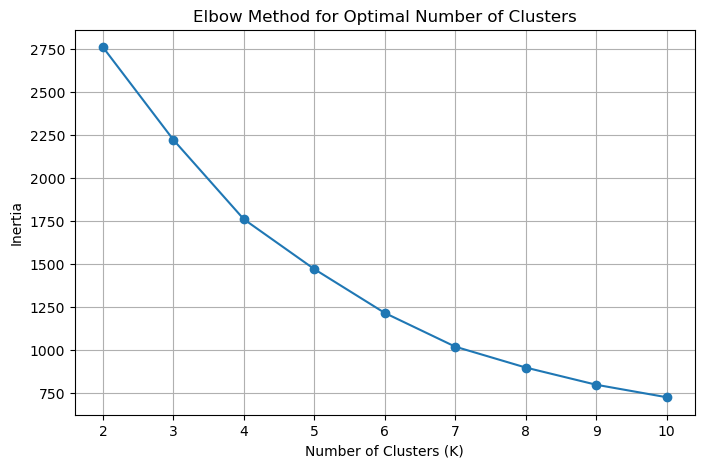

In [40]:
# Plot the Elbow Method
plt.figure(figsize=(8, 5))

plt.plot(k_values, inertia, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal Number of Clusters")

plt.xticks(k_values)
plt.grid(True)
plt.show()

### Elbow Method Observation

The inertia decreases substantially as the number of clusters increases, with the curve beginning to flatten around K = 4. This indicates that K = 4 provides a reasonable balance between reducing within-cluster variation and avoiding unnecessary additional clusters.

Therefore, K = 4 is selected as the primary clustering solution based on the Elbow Method.

## Applying K-Means Clustering

Based on the Elbow Method, four clusters were selected as the primary clustering solution. The K-Means model is trained using the standardized stock-level features.

In [41]:
# Set the final number of clusters based on the Elbow Method
optimal_k = 4

# Create and train the final K-Means model
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)

clusters = kmeans.fit_predict(X_scaled)

# Add the final cluster labels
stock_features["Cluster"] = clusters

# Display cluster counts
cluster_counts = stock_features["Cluster"].value_counts().sort_index()

print("Number of stocks in each cluster:")
print(cluster_counts)

Number of stocks in each cluster:
Cluster
0    132
1    366
2      6
3      1
Name: count, dtype: int64


### Observation

The K-Means algorithm successfully assigned each stock to one of four clusters based on similarities in price levels, trading volume, daily returns, and volatility.

## Clustering Validation

Although the Elbow Method suggested K = 5, the resulting cluster sizes are highly imbalanced. Therefore, the Silhouette Score is used as an additional validation measure to assess the quality of the clustering solution.

The Silhouette Score ranges from -1 to 1, where higher values generally indicate better-defined clusters.

In [46]:
# Calculate the Silhouette Score for the final K = 4 model
silhouette_avg = silhouette_score(X_scaled, clusters)

print(f"Silhouette Score for K = {optimal_k}: {silhouette_avg:.4f}")

Silhouette Score for K = 4: 0.3613


In [47]:
silhouette_scores = []

for k in range(2, 11):
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_temp = kmeans_temp.fit_predict(X_scaled)
    
    score = silhouette_score(X_scaled, labels_temp)
    silhouette_scores.append(score)

for k, score in zip(range(2, 11), silhouette_scores):
    print(f"K = {k}: Silhouette Score = {score:.4f}")

K = 2: Silhouette Score = 0.8449
K = 3: Silhouette Score = 0.8326
K = 4: Silhouette Score = 0.3613
K = 5: Silhouette Score = 0.3500
K = 6: Silhouette Score = 0.3483
K = 7: Silhouette Score = 0.3501
K = 8: Silhouette Score = 0.3436
K = 9: Silhouette Score = 0.2425
K = 10: Silhouette Score = 0.2511


## Silhouette Score Validation

The Silhouette Score was calculated for different values of K as an additional validation measure.

Although K = 2 and K = 3 produced higher Silhouette Scores, the Elbow Method indicated K = 4 as a suitable balance between cluster compactness and the number of clusters. Therefore, K = 4 is retained as the final solution while acknowledging that simpler cluster structures provide stronger separation.

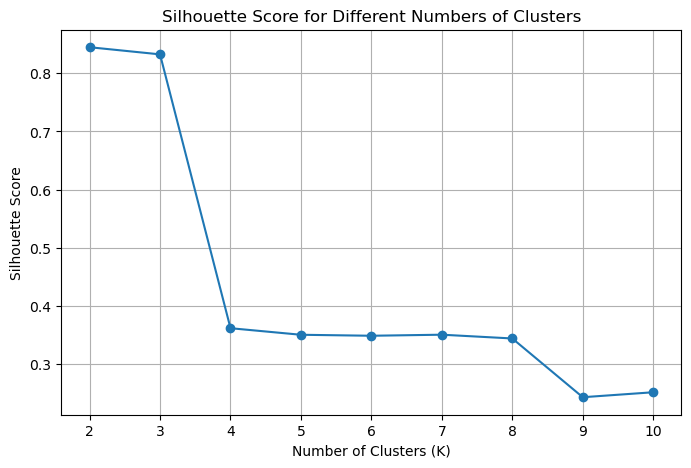

In [45]:
# Plot Silhouette Scores
plt.figure(figsize=(8, 5))

plt.plot(range(2, 11), silhouette_scores, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different Numbers of Clusters")

plt.xticks(range(2, 11))
plt.grid(True)
plt.show()

## 2D Visualization of Clusters

The stock data contains multiple numerical features, making direct visualization difficult. Principal Component Analysis (PCA) is used to reduce the standardized features to two dimensions.

The first two principal components are then used to visualize the four K-Means clusters in a 2D scatter plot.

In [48]:
# Apply PCA to reduce the features to two dimensions
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

# Create a DataFrame containing the principal components
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

# Add cluster labels
pca_df["Cluster"] = stock_features["Cluster"].values

# Display the first few rows
pca_df.head()

,PC1,PC2,Cluster
0,-0.690060,-0.439569,1
1,-1.047512,1.842265,0
2,1.178431,0.181019,1
3,-0.081519,0.659850,0
4,-0.513375,0.540267,1


In [49]:
# Display explained variance
explained_variance = pca.explained_variance_ratio_

print(f"PC1 explains {explained_variance[0] * 100:.2f}% of the variance")
print(f"PC2 explains {explained_variance[1] * 100:.2f}% of the variance")
print(f"Total variance explained: {explained_variance.sum() * 100:.2f}%")

PC1 explains 50.86% of the variance
PC2 explains 18.67% of the variance
Total variance explained: 69.54%


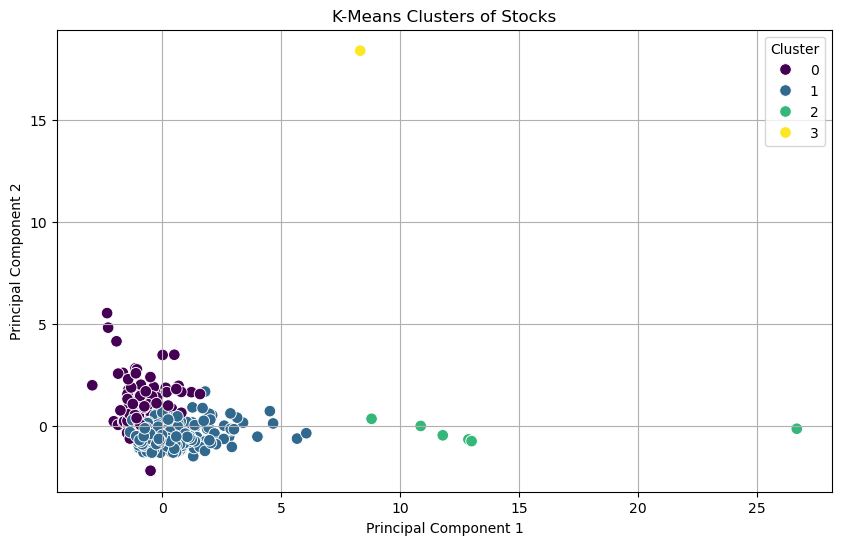

In [50]:
# Visualize the clusters using the first two principal components
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="viridis",
    s=70
)

plt.title("K-Means Clusters of Stocks")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.grid(True)
plt.show()

### 2D Visualization Observation

The PCA scatter plot provides a two-dimensional view of the four K-Means clusters. Most stocks are concentrated in the central region, while a smaller number of stocks are positioned farther away, indicating distinct stock characteristics.

The visualization also highlights the presence of a few stocks with substantially different characteristics from the majority. The exact characteristics of each cluster are examined using cluster-level feature statistics in the next section.

## Cluster Profiling and Interpretation

To understand the characteristics of each cluster, the average values of the numerical features are calculated for each cluster. These cluster profiles help identify similarities and differences in stock price levels, trading volume, returns, and volatility.

In [51]:
# Calculate average feature values for each cluster
cluster_profile = stock_features.groupby("Cluster")[features].mean()

# Display the cluster profiles
cluster_profile


,avg_open,avg_high,avg_low,avg_close,avg_volume,avg_daily_return,return_volatility,avg_daily_range
Cluster,,,,,,,,
0,48.767252,49.364709,48.133985,48.756514,8.671784e+06,-0.000011,0.017294,0.025526
1,87.047365,87.779165,86.309847,87.073466,2.697771e+06,0.000402,0.011311,0.016952
2,770.712925,777.209869,763.677823,770.611512,1.608893e+06,-0.000128,0.012466,0.018400
3,411.991296,417.951716,405.656984,412.335822,8.785884e+05,0.006973,0.224508,0.030060


In [52]:
# Round the values for easier interpretation
cluster_profile.round(4)

,avg_open,avg_high,avg_low,avg_close,avg_volume,avg_daily_return,return_volatility,avg_daily_range
Cluster,,,,,,,,
0,48.7673,49.3647,48.1340,48.7565,8.671784e+06,-0.0000,0.0173,0.0255
1,87.0474,87.7792,86.3098,87.0735,2.697771e+06,0.0004,0.0113,0.0170
2,770.7129,777.2099,763.6778,770.6115,1.608893e+06,-0.0001,0.0125,0.0184
3,411.9913,417.9517,405.6570,412.3358,8.785884e+05,0.0070,0.2245,0.0301


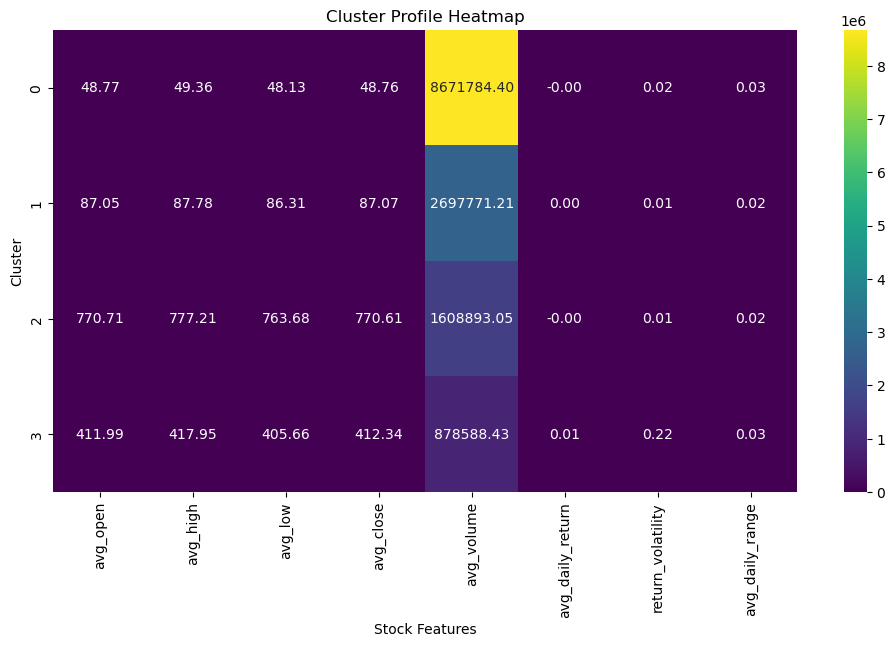

In [53]:
plt.figure(figsize=(12, 6))

sns.heatmap(
    cluster_profile,
    annot=True,
    fmt=".2f",
    cmap="viridis"
)

plt.title("Cluster Profile Heatmap")
plt.xlabel("Stock Features")
plt.ylabel("Cluster")

plt.show()

## Cluster Interpretation

The K-Means clustering produced four distinct groups of stocks with different price, trading activity, return, and volatility characteristics.

- **Cluster 0 – Lower-Priced, Highly Traded Stocks:** This cluster contains lower-priced stocks with the highest average trading volume among the four clusters. Their return volatility is moderate.

- **Cluster 1 – Moderately Priced, Relatively Stable Stocks:** This is the largest cluster. The stocks have moderate price levels, moderate trading volume, and the lowest average return volatility among the main clusters.

- **Cluster 2 – High-Priced Stocks:** This small cluster contains stocks with substantially higher average opening, high, low, and closing prices compared with Clusters 0 and 1. Their volatility remains relatively moderate.

- **Cluster 3 – Highly Volatile Outlier:** This cluster contains only one stock. It has a high average price and exceptionally high return volatility compared with the other clusters, making it a distinct outlier in the dataset.

Overall, the clustering reveals groups of stocks that differ mainly in price level, trading volume, and volatility.

## Conclusion

K-Means clustering was successfully applied to the stock price dataset after preprocessing, feature engineering, and feature scaling.

The Elbow Method indicated that K = 4 provides a suitable balance between reducing within-cluster variation and avoiding unnecessary additional clusters. Silhouette Score analysis was also performed as an additional validation measure.

The final clustering divided the stocks into four groups with different characteristics:

- Cluster 0 represents lower-priced stocks with high trading activity.
- Cluster 1 represents the largest group of moderately priced and relatively stable stocks.
- Cluster 2 represents a small group of high-priced stocks.
- Cluster 3 represents a highly unusual and volatile outlier.

The PCA visualization provided a two-dimensional representation of the clusters, while cluster profiling helped identify the main differences between the groups.

Overall, the analysis demonstrates how K-Means clustering can be used to identify groups of stocks with similar price, trading volume, return, and volatility characteristics.